# AI Impact on Jobs 2030

Analyzing how artificial intelligence is expected to affect industries, salaries, hiring trends, automation, and workforce demand by 2030.

## 1. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

data = pd.read_csv("data/AI_Impact_on_Jobs_2030.csv")
data.head(5)

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


## 2. Inspect & Clean the Data

In [2]:
data.shape

(3000, 20)

In [3]:
data.columns

Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='str')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   str    
 1   Job_Title                3000 non-null   str    
 2   Industry                 3000 non-null   str    
 3   Country                  3000 non-null   str    
 4   Education_Level          3000 non-null   str    
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   str    
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   str    
 11  Automation_Level         3000 non-null   str    
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size             3000 non-n

In [5]:
data.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [6]:
data.isnull().sum()

Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

**Data Quality Summary:** The dataset contains 3,000 records and 20 features, with no missing values or duplicate rows. Therefore, no missing-value treatment or duplicate removal was required before the exploratory analysis.

## 3. Exploratory Data Analysis

### Job Titles — Most Common Roles in the Dataset

In [8]:
data["Job_Title"].value_counts().head(10)

Job_Title
Software Developer           164
HR Specialist                163
Cybersecurity Analyst        162
Robotics Engineer            162
UX Designer                  158
Machine Learning Engineer    157
Product Manager              157
Blockchain Developer         155
Teacher                      153
DevOps Engineer              152
Name: count, dtype: int64

### Salary Analysis — Distribution, Job Title and Country

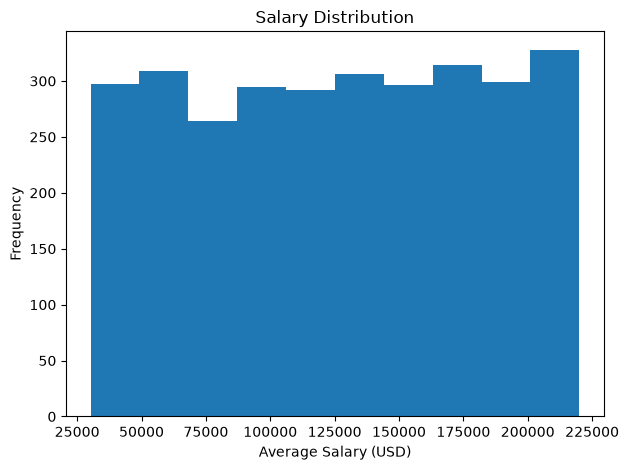

In [9]:
data["Average_Salary_USD"].plot(
    kind="hist",
    bins=10
)

plt.title("Salary Distribution")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

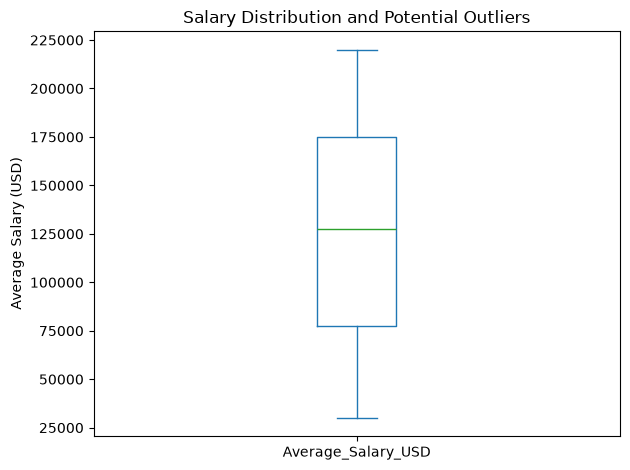

In [10]:
# Salary Box Plot

data["Average_Salary_USD"].plot(kind="box")

plt.title("Salary Distribution and Potential Outliers")
plt.ylabel("Average Salary (USD)")
plt.tight_layout()
plt.show()

In [11]:
# Top 10 highest-paying job titles by average salary
data.groupby("Job_Title")["Average_Salary_USD"].mean().sort_values(ascending=False).head(10)

Job_Title
HR Specialist       131881.742331
Cloud Architect     131847.294574
IoT Specialist      130848.791667
Business Analyst    129792.574468
Teacher             129674.267974
Data Engineer       129308.748344
Product Manager     129052.350318
Digital Marketer    128626.388060
UX Designer         126833.803797
Data Scientist      126710.236842
Name: Average_Salary_USD, dtype: float64

In [12]:
# Top 10 highest-paying countries by average salary
salary_country = (
    data.groupby("Country")["Average_Salary_USD"]
      .mean()
      .sort_values(ascending=False)
)

salary_country

Country
UK           133214.812081
Singapore    130980.434457
Australia    129039.266026
Germany      128440.735849
UAE          126109.204611
India        125810.670251
USA          124013.857627
Canada       123726.445614
Pakistan     122865.546667
Japan        122355.133779
Name: Average_Salary_USD, dtype: float64

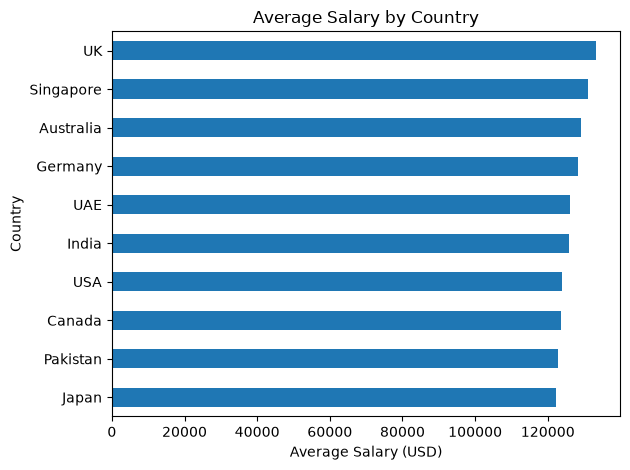

In [13]:
salary_country.sort_values().plot(kind="barh")

plt.title("Average Salary by Country")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

**Insight:** The UK has the highest average salary among the countries represented in this dataset.

### AI Replacement Risk — Overall Distribution

In [14]:
data["AI_Replacement_Risk"].describe()

count    3000.000000
mean        0.502910
std         0.261293
min         0.050000
25%         0.280000
50%         0.500000
75%         0.730000
max         0.950000
Name: AI_Replacement_Risk, dtype: float64

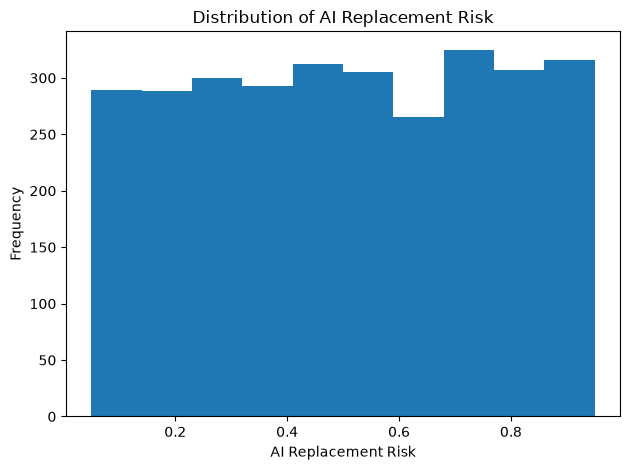

In [15]:
data["AI_Replacement_Risk"].plot(
    kind="hist",
    bins=10
)

plt.title("Distribution of AI Replacement Risk")
plt.xlabel("AI Replacement Risk")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight:** AI Replacement Risk is distributed relatively evenly across the dataset, with an average score of approximately 0.503. This indicates a mixed level of automation exposure rather than a strong concentration at either extreme.

### Future Demand — By Job Title

In [16]:
top_demand = (
    data.groupby("Job_Title")["Future_Demand_Score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_demand

Job_Title
Software Developer           0.627378
Product Manager              0.622229
Data Scientist               0.621711
Business Analyst             0.620142
Cybersecurity Analyst        0.616667
IoT Specialist               0.614167
Prompt Engineer              0.608355
Healthcare Analyst           0.603878
Teacher                      0.602876
Machine Learning Engineer    0.602420
Name: Future_Demand_Score, dtype: float64

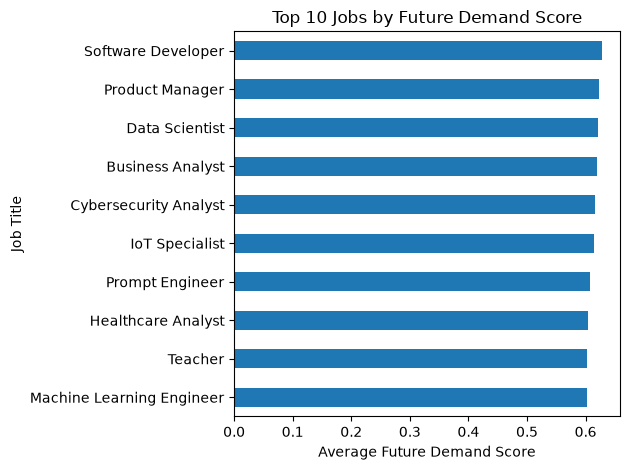

In [17]:
top_demand.sort_values().plot(kind="barh")

plt.title("Top 10 Jobs by Future Demand Score")
plt.xlabel("Average Future Demand Score")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

**Insight:** Software Developer has the highest average Future Demand Score among the job roles analyzed.

### Automation Level

In [18]:
automation_counts = data["Automation_Level"].value_counts()

automation_counts

Automation_Level
Low       1037
Medium    1011
High       952
Name: count, dtype: int64

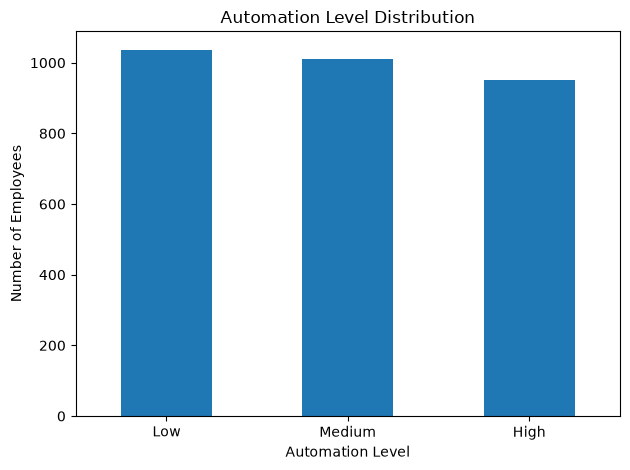

In [19]:
automation_counts.plot(kind="bar")

plt.title("Automation Level Distribution")
plt.xlabel("Automation Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Automation levels are relatively balanced across the dataset. Low automation is the most common category with 1,037 observations, followed by Medium with 1,011 and High with 952. This suggests that the dataset represents jobs across a broad range of automation exposure rather than being concentrated in a single category.

### Projected Job Growth by 2030

In [20]:
job_growth = (
    data.groupby("Job_Title")["Job_Growth_2030"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
)

job_growth

Job_Title
Blockchain Developer     18.941935
Software Developer       18.597561
Healthcare Analyst       18.537415
Data Scientist           18.427632
Data Engineer            17.860927
Business Analyst         17.787234
DevOps Engineer          17.736842
Teacher                  17.392157
Robotics Engineer        17.388889
Cybersecurity Analyst    17.283951
Name: Job_Growth_2030, dtype: float64

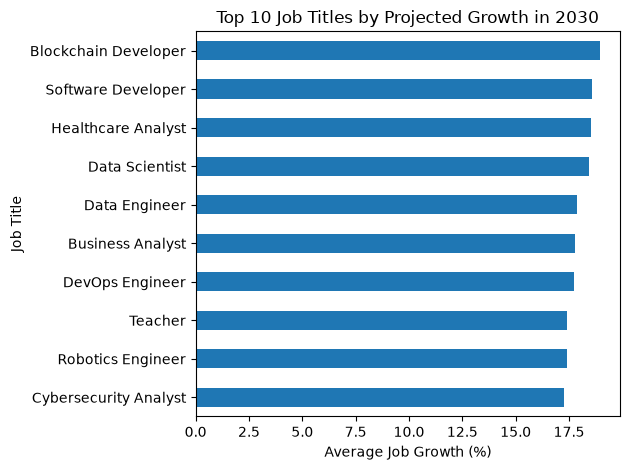

In [21]:
job_growth.sort_values().plot(kind="barh")

plt.title("Top 10 Job Titles by Projected Growth in 2030")
plt.xlabel("Average Job Growth (%)")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

**Insight:** Blockchain Developer has the highest projected average job growth at approximately 18.94%, followed by Software Developer (18.60%) and Healthcare Analyst (18.54%). Several technology-focused roles appear among the top-growth occupations, indicating strong projected growth for many technical roles in this dataset.

### Remote Work, Hiring Trends & Upskilling Needs

In [22]:
data["Remote_Work_Possibility"].value_counts()

Remote_Work_Possibility
Hybrid    1011
Yes       1003
No         986
Name: count, dtype: int64

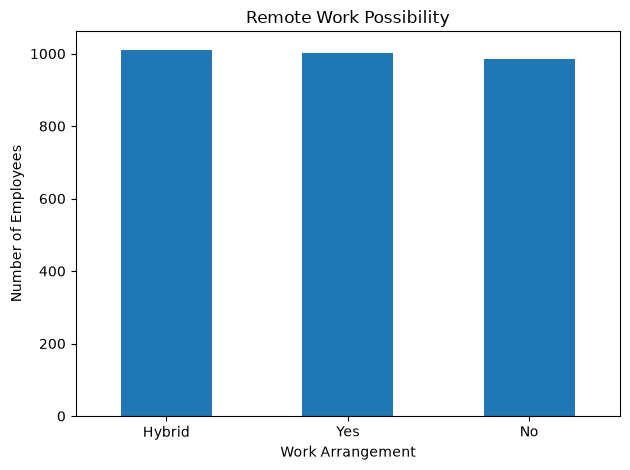

In [23]:
data["Remote_Work_Possibility"].value_counts().plot(kind="bar")

plt.title("Remote Work Possibility")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
data["Hiring_Trend_2026"].value_counts()

Hiring_Trend_2026
Growing      1010
Stable       1010
Declining     980
Name: count, dtype: int64

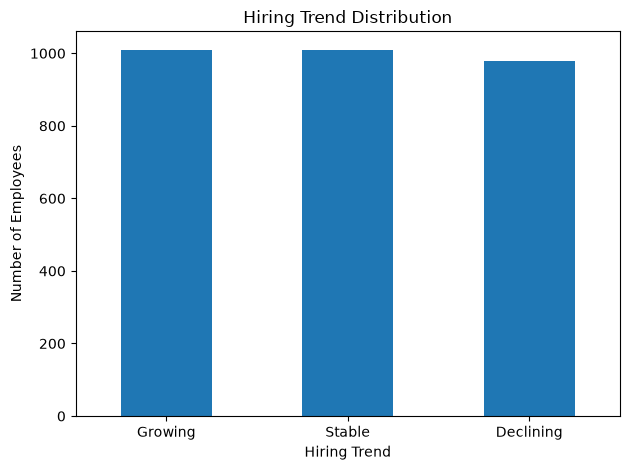

In [25]:
data["Hiring_Trend_2026"].value_counts().plot(kind="bar")

plt.title("Hiring Trend Distribution")
plt.xlabel("Hiring Trend")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Growing and Stable hiring trends are almost equally common, while Declining roles occur slightly less frequently.

In [26]:
data["Upskilling_Needed"].value_counts()

Upskilling_Needed
No     1511
Yes    1489
Name: count, dtype: int64

**Insight:** Upskilling needs are almost evenly divided in the dataset, with 1,511 observations marked "No" and 1,489 marked "Yes." This indicates that there is no strong dominance of either category in the data.

### Skills Analysis — Most Frequently Required Skills

Each row can list multiple required skills, so we split and explode the column to count individual skill frequency.

In [27]:
skill_counts = (
    data["Required_Skills"]
      .str.split(", ")
      .explode()
      .str.strip()
      .value_counts()
      .head(10)
)

skill_counts

Required_Skills
Cloud Computing       785
Leadership            778
Communication         776
Cybersecurity         776
Azure                 772
Deep Learning         770
Machine Learning      765
TensorFlow            762
Data Visualization    751
Kubernetes            750
Name: count, dtype: int64

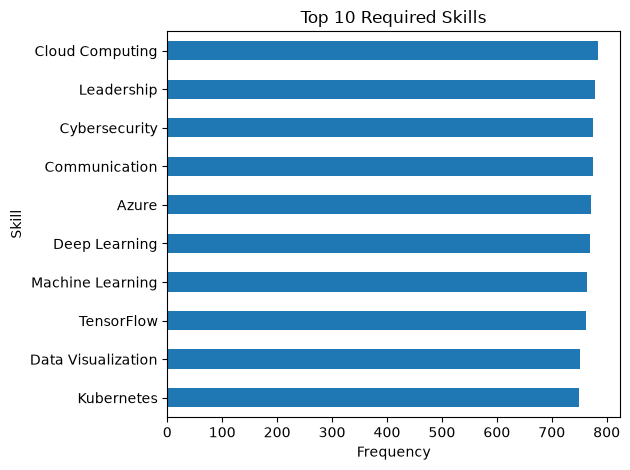

In [28]:
skill_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Required Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

**Insight:** Cloud Computing is the most frequently listed skill, while Leadership and Communication also rank highly, showing that the dataset emphasizes both technical and soft skills.

### Education vs. Salary

In [29]:
education_salary = (
    data.groupby("Education_Level")["Average_Salary_USD"]
        .mean()
        .sort_values(ascending=False)
)

education_salary

Education_Level
High School    128510.327373
Bachelor       128001.971867
PhD            125192.727856
Master         124825.217697
Name: Average_Salary_USD, dtype: float64

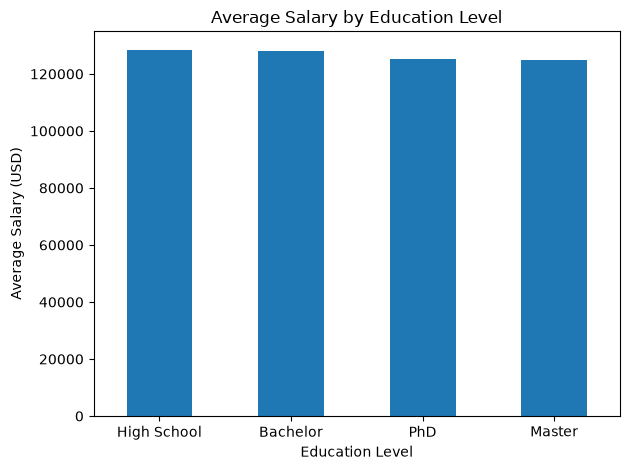

In [30]:
education_salary.plot(kind="bar")

plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Average salaries are relatively similar across education levels. In this dataset, higher education levels do not consistently correspond to higher average salaries, suggesting that salary may also be influenced by factors such as job role, experience, industry, and country.

### Experience vs. Salary

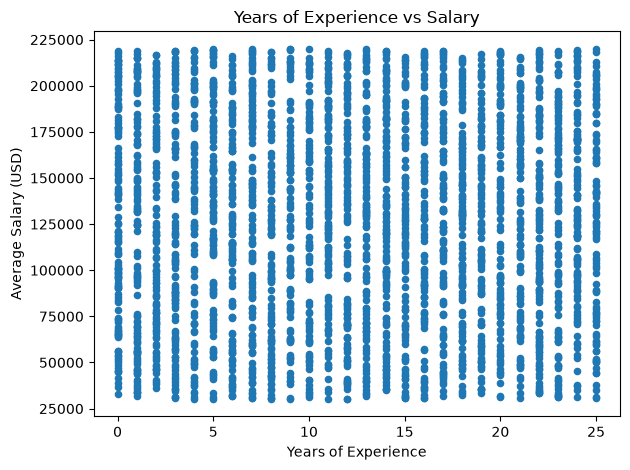

In [31]:
data.plot(
    kind="scatter",
    x="Years_Experience",
    y="Average_Salary_USD"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary (USD)")
plt.tight_layout()
plt.show()

In [32]:
correlation = data["Years_Experience"].corr(
    data["Average_Salary_USD"]
)

correlation

np.float64(0.012794759324790551)

**Insight:** The correlation is approximately 0.013, indicating little to no linear relationship between years of experience and salary in this dataset.

### AI Tool Usage Across the Workforce

In [33]:
data["AI_Tool_Usage"].value_counts()

AI_Tool_Usage
Low         1033
High        1014
Moderate     953
Name: count, dtype: int64

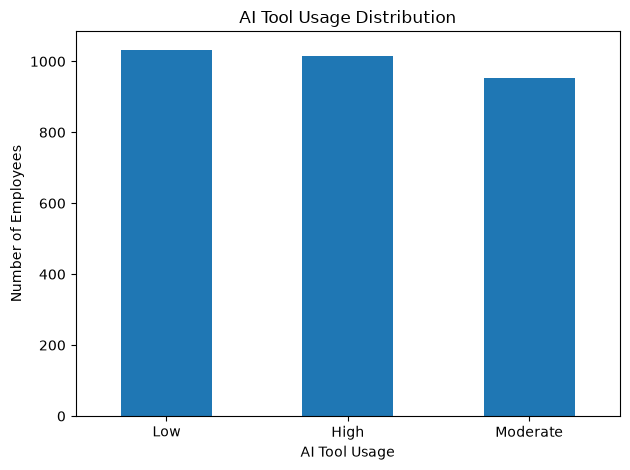

In [34]:
data["AI_Tool_Usage"].value_counts().plot(kind="bar")

plt.title("AI Tool Usage Distribution")
plt.xlabel("AI Tool Usage")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** AI tool usage is relatively balanced across Low, Moderate, and High adoption levels, with Low usage being slightly more common.

## Key Findings

### 1. Highest Paying Job
HR Specialist had the highest average salary among all job roles, with an average salary of approximately $131,882.

### 2. Highest Demand Job
Software Developer achieved the highest Future Demand Score, indicating strong demand through 2030.

### 3. Country with Highest Salaries
The United Kingdom recorded the highest average salary among all countries in the dataset.

### 4. Average AI Replacement Risk
The average AI Replacement Risk score was 0.503, suggesting a moderate level of automation risk across occupations.

### 5. Remote Work Trend
Hybrid work was the most common work arrangement, followed closely by fully remote roles. This suggests that flexible work models will remain important in the future job market.

### 6. Hiring Trend
Most jobs were classified as either Growing or Stable, indicating a generally positive employment outlook through 2026.

### 7. Automation Level
Automation exposure is fairly evenly split across the workforce — Low automation is the most common category (1,037 roles), followed closely by Medium (1,011) and High (952) — indicating no single automation tier dominates.

### 8. Projected Job Growth by 2030
Blockchain Developer leads projected job growth with an average Job Growth 2030 value of approximately 18.94, followed by Software Developer (18.60) and Healthcare Analyst (18.54), with technology-focused roles appearing prominently among the top-growth roles.

### 9. Education Analysis Insight
The analysis suggests that salary is influenced by multiple factors beyond education alone, including industry, experience, job role, and market demand.

### 10. Skills Analysis Insight
Cloud Computing, Azure, Machine Learning, Deep Learning, and Kubernetes were among the most frequently requested technical skills. Communication and Leadership also ranked highly, highlighting the importance of both technical and soft skills in AI-driven workplaces.

### 11. AI Tool Usage Insight
AI tool adoption was widespread across the workforce, with relatively balanced usage levels between Low, Moderate, and High categories. This suggests that AI technologies are becoming integrated into everyday professional workflows.

### 12. Key Takeaway
The dataset suggests varying levels of AI exposure across occupations while several technical roles continue to show strong future demand. Continuous upskilling may therefore be important as AI adoption increases across the workforce.

## Recommendations

### For Job Seekers
- Prioritize upskilling in high-demand technical areas such as Cloud Computing, Machine Learning, and Deep Learning, since these were among the most frequently required skills across roles.
- Don't neglect soft skills — Communication and Leadership also ranked highly, suggesting that a combination of technical and interpersonal skills is valuable.
- Consider roles with strong Future Demand Scores and projected growth, such as Software Developer and Blockchain Developer, when planning long-term career moves.
- Factor in AI Replacement Risk when evaluating career stability, as roles with higher automation risk may require more frequent reskilling.

### For Employers & Organizations
- Since hybrid work is the most common arrangement in the dataset, offering flexible work options may help organizations attract a broader talent pool.
- Continue investing in AI tools and employee training, as AI tool usage is already widespread across the workforce.
- Prioritize upskilling programs for roles with higher AI Replacement Risk to support workforce transition rather than displacement.

### For Policymakers & Educators
- Since salary varies across job roles, countries, industries, and experience levels, career guidance should emphasize alignment with market-demanded skills rather than degree level alone.
- Support reskilling initiatives in occupations with higher automation risk to help workers adapt to changes in the AI-driven job market.

## Conclusion

The analysis shows varying levels of AI replacement risk across occupations, alongside continued demand for several technical roles. High-demand technical roles — particularly those requiring Cloud Computing, Machine Learning, and Deep Learning skills — show strong future demand, while the moderate average AI Replacement Risk score of 0.503 suggests a mixed level of automation exposure across the occupations analyzed.

Automation exposure is broadly balanced across the workforce, while projected job growth is concentrated in technology-driven roles such as Blockchain Developer, Software Developer, and Healthcare Analyst — reinforcing that technical fluency will remain central to career resilience through 2030.

Salary and demand appear to be influenced by a combination of factors — including job role, country, industry, and market conditions — rather than education level alone. Meanwhile, the prevalence of hybrid work and widespread AI tool usage indicates that workplaces are actively adopting new technologies and work models.

The overarching takeaway is that **continuous upskilling, adaptability, and a balance of technical and soft skills** will be important for long-term career resilience in an AI-driven job market.